# Data preprocessing for GSE183852:
* DCM (5 samples): 37,128
* Healthy (2 samples): 12,595

Selected for 3000 HVGs using the healthy dataset using batch_key as the individual donors.

Pre-processing results:

**Healthy:**

Training set: 9,048 cells
Validation set: 2,262 cells
Test set: 1,257 cells

**DCM:**

Test set: 36,221


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! pip install scanpy
import scanpy as sc
import pandas as pd
import numpy as np

In [ ]:
# perform normaliziation on the original adata
adata = sc.read_h5ad("/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852/GSE183852_cleaned.h5ad")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
adata

AnnData object with n_obs × n_vars = 49723 × 33538
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names'
    var: 'gene_symbol'
    uns: 'log1p'

In [ ]:
print(adata.obs.groupby('Condition', observed=True)['orig.ident'].unique())
# HDCM 1,3,4,,6,8 are samples with cardiovascular disease

Condition
DCM      ['HDCM1', 'HDCM3', 'HDCM4', 'HDCM6', 'HDCM8']
...
Donor    ['HDCM5', 'HDCM7']
Categories (7, object): ['H...
Name: orig.ident, dtype: object


In [ ]:
print(adata.obs['percent.mito'].describe())
print(adata.obs['nFeature_RNA'].describe())

count    49723.000000
mean         4.738176
std          2.101225
min          0.000000
25%          3.132427
50%          4.338057
75%          6.142946
max          9.998279
Name: percent.mito, dtype: float64
count    49723.000000
mean      1966.243067
std        604.899949
min        217.000000
25%       1466.000000
50%       1863.000000
75%       2417.000000
max       4032.000000
Name: nFeature_RNA, dtype: float64


In [ ]:
# plot cell count across patient and between conditions
cell_counts = adata.obs.groupby(['Condition', 'orig.ident'], observed=True).size()
print(cell_counts)

condition_counts = adata.obs.groupby('Condition', observed=True)['orig.ident'].count()
print(condition_counts)

Condition  orig.ident
DCM        HDCM1         7430
           HDCM3         7428
           HDCM4         8223
           HDCM6         8784
           HDCM8         5263
Donor      HDCM5         7032
           HDCM7         5563
dtype: int64
Condition
DCM      37128
Donor    12595
Name: orig.ident, dtype: int64


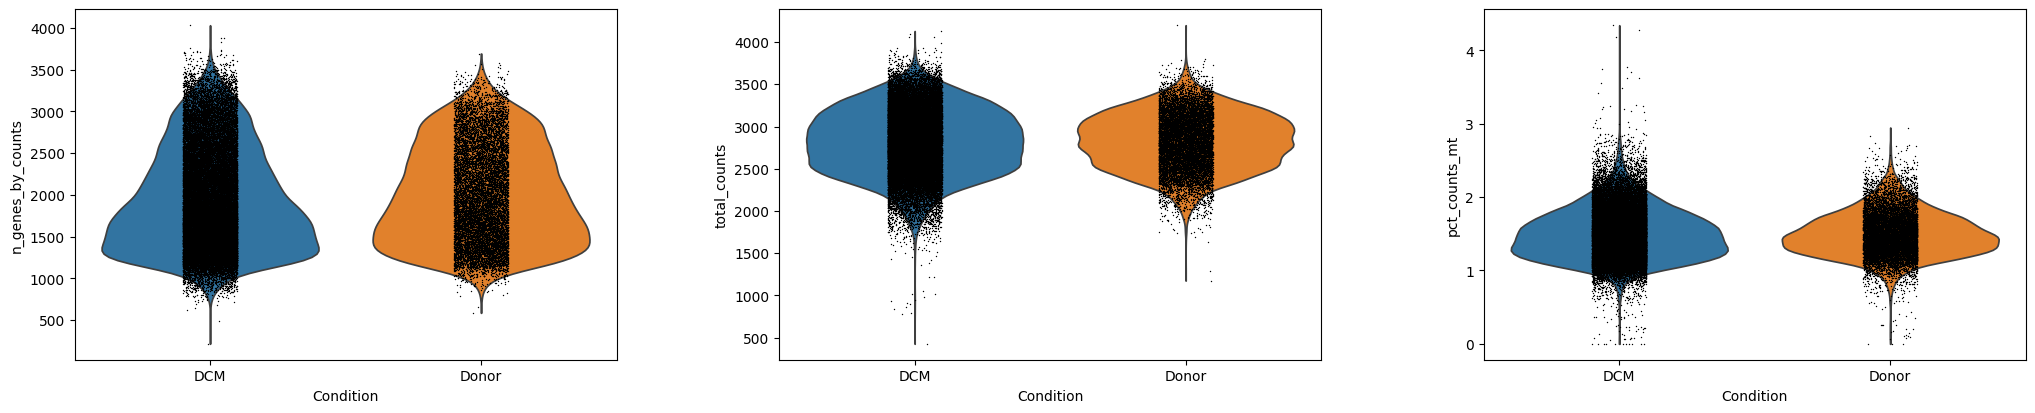

In [ ]:
# Plot mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='Condition', multi_panel=True)

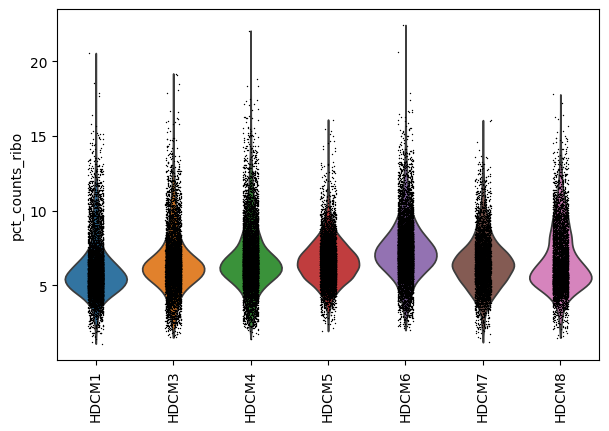

In [ ]:
# plot ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
sc.pp.calculate_qc_metrics(adata, qc_vars=['ribo'], inplace=True, percent_top=None)

sc.pl.violin(adata, ['pct_counts_ribo'], groupby='orig.ident', rotation=90)

In [ ]:
healthy_counts = adata[adata.obs['Condition'] == 'Donor'].obs['Names'].value_counts()
print(healthy_counts)

Names
Fibroblasts      6873
Endothelium      3171
Pericytes        1049
Macrophages       653
Smooth_Muscle     287
T_Cells           274
Monocytes         174
NK_Cells           86
Neurons            18
B_Cells             7
Lymphatic           3
Name: count, dtype: int64


In [ ]:
print(adata[adata.obs['Condition'] == 'DCM'].obs['Names'].value_counts())

Names
Fibroblasts      16676
Endothelium       8405
Pericytes         4634
Macrophages       3391
T_Cells           2073
Smooth_Muscle      601
Monocytes          513
NK_Cells           328
Neurons            297
B_Cells            176
Lymphatic           34
Name: count, dtype: int64


In [ ]:
adata.var['gene_name'] = adata.var.index
adata.obs['celltype'] = adata.obs['Names']

In [ ]:
# perform normaliziation on the original adata
adata_healthy = adata[adata.obs['Condition'] == 'Donor'].copy()
# keep only the cell type with >= 50 cell count
reliable_types = healthy_counts[healthy_counts >= 50].index.tolist()
adata_healthy = adata_healthy[adata_healthy.obs['Names'].isin(reliable_types)].copy()
adata_healthy.obs['Names'] = adata_healthy.obs['Names'].cat.remove_unused_categories()

In [ ]:
# perform HVG selection on the healthy subset and batch_key by patient:
sc.pp.highly_variable_genes(
    adata_healthy,
    n_top_genes=3000,
    batch_key='orig.ident',
    subset=True
)

adata = adata[:, adata_healthy.var_names].copy()

In [ ]:
# split into training to training and validation:
from sklearn.model_selection import train_test_split
seed = 36

indices = np.arange(adata_healthy.n_obs)

healthy_idx, healthy_test_idx = train_test_split(
    indices,
    test_size=0.1,
    random_state=seed,
    stratify=adata_healthy.obs['Names']
)

train_idx, val_idx = train_test_split(
    healthy_idx,
    test_size=0.2,
    random_state=seed,
    stratify=adata_healthy.obs['Names'].iloc[healthy_idx]
)

train_data = adata_healthy[train_idx].copy()
valid_data = adata_healthy[val_idx].copy()
healthy_test_data = adata_healthy[healthy_test_idx].copy()

# get test data:
DCM_test_data = adata[adata.obs['Condition'] == 'DCM'].copy()
train_classes = set(train_data.obs['celltype'])
DCM_test_data = DCM_test_data[
    DCM_test_data.obs['celltype'].isin(train_classes)
].copy()

In [ ]:
train_data = train_data[:, adata_healthy.var_names]
valid_data = valid_data[:, adata_healthy.var_names]
DCM_test_data = DCM_test_data[:, adata_healthy.var_names]

In [ ]:
print((train_data.var_names == DCM_test_data.var_names).all())

True


In [ ]:
print(DCM_test_data.obs['Names'].value_counts())
print(healthy_test_data.obs['Names'].value_counts())
print(valid_data.obs['Names'].value_counts())
print(train_data.obs['Names'].value_counts())

Names
Fibroblasts      16676
Endothelium       8405
Pericytes         4634
Macrophages       3391
T_Cells           2073
Smooth_Muscle      601
Monocytes          513
NK_Cells           328
Name: count, dtype: int64
Names
Fibroblasts      688
Endothelium      317
Pericytes        105
Macrophages       65
Smooth_Muscle     29
T_Cells           27
Monocytes         17
NK_Cells           9
Name: count, dtype: int64
Names
Fibroblasts      1237
Endothelium       571
Pericytes         189
Macrophages       118
Smooth_Muscle      52
T_Cells            49
Monocytes          31
NK_Cells           15
Name: count, dtype: int64
Names
Fibroblasts      4948
Endothelium      2283
Pericytes         755
Macrophages       470
Smooth_Muscle     206
T_Cells           198
Monocytes         126
NK_Cells           62
Name: count, dtype: int64


In [ ]:
# Save the datasets as h5ad file:
#train_data.write("/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/train_set_1.h5ad")
#valid_data.write("/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/validation_set_1.h5ad")
#DCM_test_data.write("/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/DCM_test_set_1.h5ad")
#healthy_test_data.write("/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/healthy_test_set_1.h5ad")